
Fixed-Point Iteration for g(x) = g1
Iter |          x_k | Δ_k = |x_k - x_{k-1}|
------------------------------------------
   1 |   2.13666667 |       3.66666667e-02
   2 |   2.18844815 |       5.17814815e-02
   3 |   2.26310177 |       7.46536176e-02
   4 |   2.37387653 |       1.10774768e-01
   5 |   2.54509660 |       1.71220066e-01
   6 |   2.82583890 |       2.80742301e-01
   7 |   3.32845516 |       5.02616263e-01
   8 |   4.35953793 |       1.03108276e+00
   9 |   7.00185697 |       2.64231905e+00
  10 |  17.00866703 |       1.00068101e+01
  11 |  97.09825135 |       8.00895843e+01
  12 | 3143.35680503 |       3.04625855e+03
  13 | 3293564.66789901 |       3.29042131e+06
  14 | 3615856073878.22900391 |       3.61585278e+12
  15 | 4358138382334026789683200.00000000 |       4.35813838e+24
  16 | 6331123386524348849636345758230004602494829723648.00000000 |       6.33112339e+48
  17 | 13361041111798512330613554508707854862056793549931214794627672827182614477313037299538761705586688

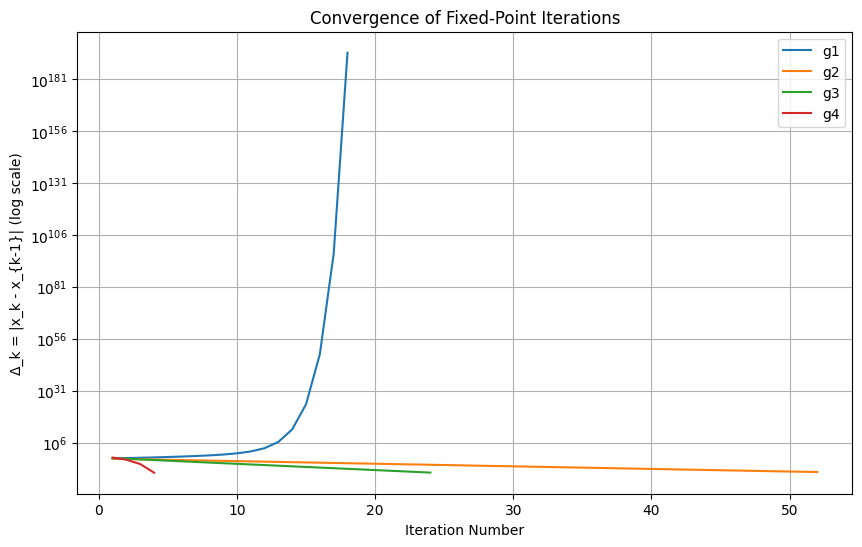

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 定义四个不动点迭代函数
def g1(x): return (x**2 + 2) / 3
def g2(x): return np.sqrt(3 * x - 2)
def g3(x): return 3 - 2 / x
def g4(x): return (x**2 - 2) / (2 * x - 3)

# 不动点迭代函数（带信息输出）
def fixed_point_iteration(g, x0, tol=1e-8, max_iter=80):
    print(f"\nFixed-Point Iteration for g(x) = {g.__name__}")
    print(f"{'Iter':>4} | {'x_k':>12} | {'Δ_k = |x_k - x_{k-1}|':>20}")
    print("-" * 42)

    x_values = [x0]
    deltas = []

    for k in range(1, max_iter + 1):
        try:
            x1 = g(x0)
        except Exception as e:
            print(f"Iteration {k}: Error encountered - {e}")
            break
        delta = abs(x1 - x0)
        x_values.append(x1)
        deltas.append(delta)

        print(f"{k:4d} | {x1:12.8f} | {delta:20.8e}")

        if delta < tol:
            print("Converged")
            break
        x0 = x1
    else:
        print("Did not converge")

    return x_values, deltas

# 主函数：运行所有 g_i(x) 的不动点迭代
def run_all_iterations(x0=2.1):
    funcs = [g1, g2, g3, g4]
    results = {}

    for g in funcs:
        x_vals, deltas = fixed_point_iteration(g, x0)
        results[g.__name__] = deltas  # 仅保留误差用于绘图

    # 绘制误差收敛图像（对数纵轴）
    plt.figure(figsize=(10, 6))
    for name, deltas in results.items():
        plt.plot(range(1, len(deltas) + 1), deltas, label=name)
    plt.yscale('log')
    plt.xlabel("Iteration Number")
    plt.ylabel("Δ_k = |x_k - x_{k-1}| (log scale)")
    plt.title("Convergence of Fixed-Point Iterations")
    plt.legend()
    plt.grid(True)
    plt.show()

# 执行所有函数的迭代
run_all_iterations(x0=2.1)  # 初始点略微偏离 x = 2，用于验证收敛
